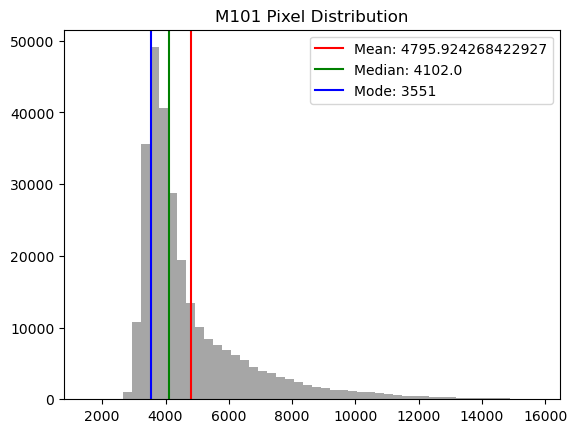

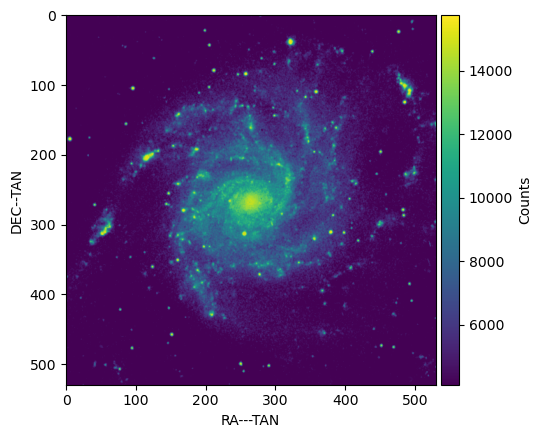

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdul = fits.open('m101.fits')
header = hdul[0].header
dat = hdul[0].data
print()

flat_dat = dat.flatten()
mn, mx = np.min(flat_dat), np.max(flat_dat)
avg, med = np.mean(flat_dat), np.median(flat_dat)
mode_val = stats.mode(flat_dat, keepdims=True).mode[0]

fig, ax = plt.subplots()
ax.hist(flat_dat, bins=50, color='gray', alpha=0.7)
ax.axvline(avg, color='r', label=f'Mean: {avg}')
ax.axvline(med, color='g', label=f'Median: {med}')
ax.axvline(mode_val, color='b', label=f'Mode: {mode_val}')
ax.set_title("M101 Pixel Distribution")
ax.legend()

dat_float = np.asarray(dat, dtype=float)
fig_img, ax_img = plt.subplots()
im = ax_img.imshow(dat_float, cmap='viridis', vmin=med)

ax_img.set_xlabel(header['CTYPE1'])
ax_img.set_ylabel(header['CTYPE2'])

divider = make_axes_locatable(ax_img)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig_img.colorbar(im, cax=cax)
cbar.set_label("Counts")

header['BUNIT'] = 'Counts'
new_hdu = fits.PrimaryHDU(dat_float, header=header)
new_hdu.writeto('m101_processed.fits', overwrite=True, output_verify='silentfix')

In [2]:
#Question 6.3

import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

hdul = fits.open('m101.fits')
data = hdul[0].data.astype(np.float64)


noise_slice = data[100:120, 100:120]
pixels = noise_slice.flatten()

n = len(pixels)
rms = np.sqrt(np.mean(pixels**2))
mean = np.mean(pixels)
std_dev = np.std(pixels)

print(f"RMS: {rms}")
print(f"Mean: {mean}")
print(f"Standard Deviation: {std_dev}")


RMS: 3587.3731068150687
Mean: 3578.1725
Standard Deviation: 256.76325232351684


In [11]:
#Question 6.5
import numpy as np
from astropy.io import fits

file_names = ['noisemap0.fits', 'noisemap1.fits', 'noisemap2.fits']
data_list = [fits.getdata(f) for f in file_names]

sigmas = [np.std(data) for data in data_list]
for i, s in enumerate(sigmas):
    print(f"Standard deviation of noisemap{i}: {s}")

stacked_data = np.stack(data_list, axis=0)

mean_image = np.mean(stacked_data, axis=0)

sigma_mean_measured = np.std(mean_image)
print(f"Measured sigma of the mean image: {sigma_mean_measured}")

sum_sq_sigmas = sum([s**2 for s in sigmas])
sigma_theoretical = (1/len(data_list)) * np.sqrt(sum_sq_sigmas)

print(f"Theoretical sigma (from formula): {sigma_theoretical}")
print(f"Difference: {abs(sigma_mean_measured - sigma_theoretical)}")


Standard deviation of noisemap0: 9.98401556679484
Standard deviation of noisemap1: 10.003955116338458
Standard deviation of noisemap2: 9.995349488722516
Measured sigma of the mean image: 5.773191380233297
Theoretical sigma (from formula): 5.770294583366139
Difference: 0.002896796867157825


In [6]:
#Question 6.6
import numpy as np
from astropy.io import fits
from astropy.table import Table

hdul = fits.open('APOGEE_stars.fits')
t = hdul[1].data 

mask = (
    (t['STARFLAG'] == 0) & 
    (t['ASPCAPFLAG'] == 0) & 
    (t['SNR'] > 10) & 
    (t['GAIAEDR3_PARALLAX'] > 0) &
    (t['GAIAEDR3_PARALLAX'] / t['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(t['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

t['DATAFLAG'] = 0
t['DATAFLAG'][mask] = 1

m_G = t['GAIAEDR3_PHOT_G_MEAN_MAG']
plx = t['GAIAEDR3_PARALLAX']

with np.errstate(invalid='ignore', divide='ignore'):
    t['ABS_MAG_G'] = m_G + 5 * np.log10(plx / 1000.0) + 5

t['ABS_MAG_G'][t['DATAFLAG'] == 0] = -1.0

t.write('APOGEE_update.fits', overwrite=True)

print("File 'APOGEE_update.fits' has been created successfully.")
print(f"Columns added: DATAFLAG, ABS_MAG_G")


TypeError: buffer is too small for requested array

Row with the maximum phot_g_mean_flux:
source_id                  1.741834e+07
ra                         2.358429e+02
ra_error                   5.007553e-03
dec                        1.171101e+01
dec_error                  4.450002e-03
phot_g_mean_flux           4.248940e+07
phot_g_mean_flux_error     5.649703e+03
phot_g_mean_mag            6.617699e+00
phot_bp_mean_flux          1.572251e+07
phot_bp_mean_flux_error    9.947167e+03
phot_bp_mean_mag           7.360095e+00
phot_rp_mean_flux          3.165592e+07
phot_rp_mean_flux_error    2.005618e+04
phot_rp_mean_mag           6.010764e+00
a_g_val                    0.000000e+00
e_bp_min_rp_val            0.000000e+00
Name: 64, dtype: float64
------------------------------


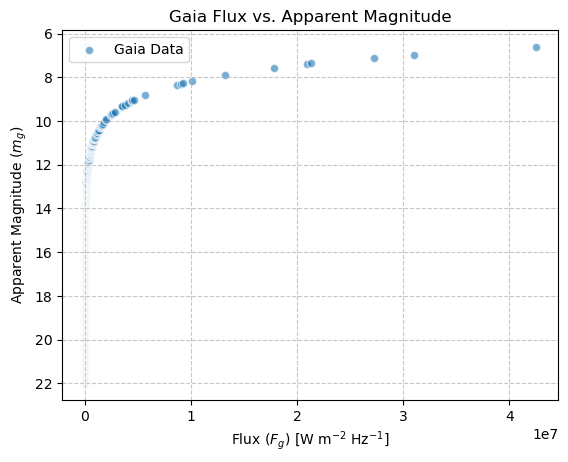

Calculated average value for m0: 25.68840037029544


In [16]:
#Question 6.7

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('gaiaTestData.csv')

max_flux_row = df.loc[df['phot_g_mean_flux'].idxmax()]
print("Row with the maximum phot_g_mean_flux:")
print(max_flux_row)
print("-" * 30)

df_sorted = df.sort_values(by='phot_g_mean_flux')

fig, ax = plt.subplots()
ax.scatter(df_sorted['phot_g_mean_flux'], df_sorted['phot_g_mean_mag'], 
           alpha=0.6, edgecolors='w', label='Gaia Data')

ax.set_xlabel('Flux ($F_g$) [W m$^{-2}$ Hz$^{-1}$]')
ax.set_ylabel('Apparent Magnitude ($m_g$)')
ax.set_title('Gaia Flux vs. Apparent Magnitude')
ax.invert_yaxis()  # Standard practice: brighter stars (lower magnitude) at the top
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.show()

m0_array = df['phot_g_mean_mag'] + 2.5 * np.log10(df['phot_g_mean_flux'])
m0_average = m0_array.mean()

print(f"Calculated average value for m0: {m0_average}")


In [1]:
#Question 6.10

from astroquery.gaia import Gaia
import pandas as pd
from astropy.table import Table

query = """
SELECT TOP 50 
    source_id, ra, dec, parallax, parallax_error, 
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

job = Gaia.launch_job(query)
results_table = job.get_results()

df = results_table.to_pandas()

print("First 5 rows of the retrieved data:")
print(df.head())

results_table.write('astroquery_gaia.fits', format='fits', overwrite=True)

print("File 'astroquery_gaia.fits' has been successfully created.")


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
First 5 rows of the retrieved data:
             source_id          ra        dec  parallax  parallax_error  \
0  4267180339403392768  286.716913   0.276195  1.084924        0.033431   
1  6709252873623174016  276.691194 -46.105121  0.206682        0.040105   
2  4040949706019490560  265.229363 -36.358205  0.352725        0.029665   
3  4517539583701880064  284.025662  18.403039  0.674962        0.040008   
4  1823532754729083392  300.805804  20.601006  0.886435        0.020054   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag 

In [1]:
#Question 6.14

class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    
    def __init__(self, n, m) :
        self.n = n 
        self.m = m 
  
    def get_nth_term(self):
        """Returns the Nth term of the Fibonacci sequence."""
        if self.n <= 0: return None
        if self.n == 1: return 0
        if self.n == 2: return 1
        
        a, b = 0, 1
        for _ in range(self.n - 2):
            a, b = b, a + b
        return b

    def get_divisible_by_m(self):
        """Returns all Fibonacci numbers preceding the Nth term that are divisible by M."""
        divisible_numbers = []
        a, b = 0, 1
        
        for _ in range(1, self.n):
            if a % self.m == 0:
                divisible_numbers.append(a)
            a, b = b, a + b
            
        return divisible_numbers


fibo = Fibonacci(100, 7)

nth_term = fibo.get_nth_term()

divisible_list = fibo.get_divisible_by_m()

print(f"The {self.n}-th Fibonacci term is:{nth_term}")
print(f"Fibonacci numbers before the {n_val}-th term divisible by {m_val}:")
print(divisible_list)

NameError: name 'self' is not defined